In [1]:
def read_block(path):
    lines = []
    with open(path) as f:
        lines = f.read().split('\n')
    
    block = {}
    for line in lines:
        if line.isdigit():
            current_size = int(line)
            block[current_size] = []
        elif line.startswith("Block Size? Time:"):
            time = float(line.split(":")[1].split()[0])
        elif line.startswith("L1 DCM:"):
            l1_dcm = int(line.split(":")[1].strip())
        elif line.startswith("L2 DCM:"):
            l2_dcm = int(line.split(":")[1].strip())
            if current_size is not None:
                block[current_size].append((time, l1_dcm, l2_dcm))
    
    return block


def read_multi_cpp(path):
    lines = []
    with open(path) as f:
        lines = f.read().split('\n')
    
    block = {}
    for line in lines:
        if line.isdigit():
            current_size = int(line)
            block[current_size] = []
        elif line.startswith("Time:"):
            time = float(line.split(":")[1].split()[0])
        elif line.startswith("L1 DCM:"):
            l1_dcm = int(line.split(":")[1].strip())
        elif line.startswith("L2 DCM:"):
            l2_dcm = int(line.split(":")[1].strip())
            if current_size is not None:
                block[current_size].append((time, l1_dcm, l2_dcm))
    
    return block


def read_multi_java(path):
    lines = []
    with open(path) as f:
        lines = f.read().split('\n')
    
    block = {}
    for line in lines:
        if line.isdigit():
            current_size = int(line)
            block[current_size] = []
        elif line.startswith("Time:"):
            time = float(line.split(":")[1].split()[0])
            if current_size is not None:
                block[current_size].append(time) 
    
    return block

# For getting the averages
def mean_values(lst):
    sums = [0, 0, 0]
    for t, l1, l2 in lst:
        sums[0] += t
        sums[1] += l1
        sums[2] += l2

    tot = len(lst)
    return (sums[0]/tot, sums[1]/tot, sums[2]/tot)


def get_mean_cpp(d):
    new_b = {}
    for k, v in d.items():
        new_b[k] = mean_values(v)
    return new_b


def get_mean_java(d):
    from statistics import mean

    new_b = {}
    for k, v in d.items():
        new_b[k] = mean(v)
    return new_b

In [2]:
# All values - C
block_128 = read_block("block_multi_128.txt")
block_256 = read_block("block_multi_256.txt")
block_512 = read_block("block_multi_512.txt")
line_multi_cpp = read_multi_cpp("line_multi_cpp.txt")
multi_cpp = read_multi_cpp("multi_cpp.txt")

line_multi_big_cpp = read_multi_cpp("line_multi_big.txt")
line_multi_parallel1 = read_multi_cpp("line_multi_parallel1.txt")
line_multi_parallel2 = read_multi_cpp("line_multi_parallel2.txt")

# All values - Java
line_multi_java = read_multi_java("line_multi_java.txt")
multi_java = read_multi_java("multi_java.txt")

# Avg. values - C
new_block_128 = get_mean_cpp(block_128)
new_block_256 = get_mean_cpp(block_256)
new_block_512 = get_mean_cpp(block_512)
new_line_multi_cpp = get_mean_cpp(line_multi_cpp)
new_multi_cpp = get_mean_cpp(multi_cpp)

new_multi_big_cpp = get_mean_cpp(line_multi_big_cpp)
new_multi_parallel1 = get_mean_cpp(line_multi_parallel1)
new_multi_parallel2 = get_mean_cpp(line_multi_parallel2)

# Avg. values - Java
new_line_multi_java = get_mean_java(line_multi_java)
new_multi_java = get_mean_java(multi_java)

In [3]:
mflops = lambda n, time : 2 * n**3 / (time * 10**9)
speedup = lambda ts, tp : ts / tp
efficiency = lambda speedup, cores : speedup / cores

In [4]:
def general_analyser_cpp(d):
    res = {}

    for k, v in d.items():
        res[k] = (mflops(k, v[0]))
    
    return res

def general_analyser_java(d):
    res = {}

    for k, v in d.items():
        res[k] = (mflops(k, v))
    
    return res

def line_analyser(d):
    res = {}
    
    for k, v in d.items():
        speed = speedup(v[0], 1) # TODO Change second parameter !
        res[k] = (mflops(k, v[0]), speed, efficiency(speed, 16))
    
    return res

def parallel_analyser(d):
    res = {}
    
    for k, v in d.items():
        speed = speedup(new_multi_big_cpp[k][0], v[0])
        res[k] = (mflops(k, v[0]), speed, efficiency(speed, 16))
    
    return res


res_block_128 = general_analyser_cpp(new_block_128)
res_block_256 = general_analyser_cpp(new_block_256)
res_block_512 = general_analyser_cpp(new_block_512)
res_multi_cpp = general_analyser_cpp(new_multi_cpp)
res_multi_java = general_analyser_java(new_multi_java)
res_line_multi_java = general_analyser_java(new_line_multi_java)
res_line_multi_cpp = line_analyser(new_line_multi_cpp)

In [5]:
def speedup_parallel():
    import matplotlib.pyplot as plt

    data = [
        ('Normal - C++', new_multi_cpp),
        ('Normal - java', new_multi_java),
        ('Line - C++', new_line_multi_cpp),
        ('Line - java', new_line_multi_java)
    ]

    colors = ["darkblue", "cornflowerblue", "lightgreen", "darkgreen"]

    for c, (label, vals) in enumerate(data):
        x = vals.keys()
        y = []
        for v in vals.values():
            if type(v) is tuple: y.append(v[0])
            else: y.append(v)
        plt.plot(x, y, label = label, marker='o', markersize=4, color=colors[c])
    
    plt.xlabel('Matrix Size')
    plt.ylabel(f'Time (s)')
    
    plt.legend()

    plt.show()

In [6]:
def time_multi():
    import matplotlib.pyplot as plt

    data = [
        ('Normal - C++', new_multi_cpp),
        ('Normal - java', new_multi_java),
        ('Line - C++', new_line_multi_cpp),
        ('Line - java', new_line_multi_java)
    ]

    colors = ["darkblue", "cornflowerblue", "lightgreen", "darkgreen"]

    for c, (label, vals) in enumerate(data):
        x = vals.keys()
        y = []
        for v in vals.values():
            if type(v) is tuple: y.append(v[0])
            else: y.append(v)
        plt.plot(x, y, label = label, marker='o', markersize=4, color=colors[c])
    
    plt.xlabel('Matrix Size')
    plt.ylabel(f'Time (s)')
    
    plt.legend()

    description = "Graph 1: Execution time for problem 1 and 2"
    plt.text(0.5, -0.15, description, horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=11)


    plt.show()

In [7]:
def cache_misses_multi(cache):
    import matplotlib.pyplot as plt

    data = [
        (f'Cache Misses L{cache} - Normal - C++', new_multi_cpp),
        (f'Cache Misses L{cache} - Line - C++', new_line_multi_cpp)
    ]

    colors = ["navy", "cornflowerblue", "mediumseagreen"]

    for c, (label, vals) in enumerate(data):
        x = vals.keys()
        y = [v[cache] / 10**9 for v in vals.values()]
        plt.plot(x, y, label = label, marker='o', markersize=4, color=colors[c])
    
    plt.xlabel('Matrix Size')
    plt.ylabel(f'Cache L{cache} misses (10\u2079)')
    
    plt.legend()

    if (cache == 1):
        description = "Graph 3: Cache L1 misses in C++ for problem 1 and 2"
    else:
        description = "Graph 4: Cache L2 misses in C++ for problem 1 and 2"
    plt.text(0.5, -0.15, description, horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=11)


    plt.show()

def cache_misses_multi1(cache):
    import matplotlib.pyplot as plt
    import numpy as np

    data = [
        (f'Cache Misses L{cache} - Normal - C++', new_multi_cpp),
        (f'Cache Misses L{cache} - Line - C++', new_line_multi_cpp)
    ]

    sizes = tuple(list(new_block_128.keys()))
    misses = {
        'Normal': tuple(v[cache] / 10**9 for v in new_multi_cpp.values()),
        'Line': tuple (v[cache] / 10**9 for v in new_multi_cpp.values()),
        # TODO - Uncomment when having new results
        #'Line': tuple(v[cache] / 10**9 for k, v in new_line_multi_cpp.items() if k in sizes)
    }

    x = np.arange(len(sizes))
    acc = 0
    fig, ax = plt.subplots(layout='constrained')
    colors= ["navy", "blue", "cornflowerblue", "lightblue"]

    for attribute, measure in misses.items():
        offset = 0.2 * acc
        ax.bar(x + offset, measure, 0.2, label=attribute, color=colors[acc])
        acc += 1


    ax.set_xlabel('Matrix Size')
    ax.set_xticks(x + 0.2, sizes)
    ax.set_ylabel(f'Cache L{cache} misses (10\u2079)')
    ax.legend()


    plt.show()


In [8]:
def time_block():
    import matplotlib.pyplot as plt

    data = [
        ('128', new_block_128),
        ('256', new_block_256),
        ('512', new_block_512),
        ('line', new_multi_big_cpp)
    ]
    
    colors = ["darkblue", "cornflowerblue", "lightgreen", "darkgreen"]

    for c, (label, vals) in enumerate(data):
        x = vals.keys()
        y = [v[0] for v in vals.values()]
        plt.plot(x, y, label = label, marker='o', markersize=4, color=colors[c])
    
    plt.xlabel('Matrix Size')
    plt.ylabel(f'Time (s)')
    
    plt.legend()

    description = "Graph 5: Execution time for problem 2 and 3"
    plt.text(0.5, -0.15, description, horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=11)

    plt.show()

In [9]:
def flops_block():
    import matplotlib.pyplot as plt

    data = [
    ('128', res_block_128),
    ('256', res_block_256),
    ('512', res_block_512)
    ]

    colors = ["navy", "cornflowerblue", "mediumseagreen"]

    for c, (label, vals) in enumerate(data):
        x = vals.keys()
        y = [v for v in vals.values()]
        plt.plot(x, y, label = label, marker='o', markersize=4, color=colors[c])

    plt.xlabel('Matrix Size')
    plt.ylabel('MFLOPS')

    plt.legend()

    description = "Graph 6: FLOPS for problem 3"
    plt.text(0.5, -0.15, description, horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=11)
    
    plt.show()

def flops_multi():
    import matplotlib.pyplot as plt

    data = [
    ('Normal - C++', res_multi_cpp),
    ('Normal - java', res_multi_java),
    ('Line - C++', res_line_multi_cpp),
    ('Line - java', res_line_multi_java)
    ]

    colors = ["darkblue", "cornflowerblue", "lightgreen", "darkgreen"]

    for c, (label, vals) in enumerate(data):
        x = vals.keys()

        y = []
        for v in vals.values():
            if type(v) is tuple: y.append(v[0])
            else: y.append(v)
        plt.plot(x, y, label = label, marker='o', markersize=4, color=colors[c])

    plt.xlabel('Matrix Size')
    plt.ylabel('MFLOPS')

    plt.legend()

    description = "Graph 2: FLOPS for problem 1 and 2"
    plt.text(0.5, -0.15, description, horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=11)
    plt.show()


In [10]:
def cache_misses_block(cache):
    import matplotlib.pyplot as plt
    import numpy as np

    sizes = tuple(list(new_block_128.keys()))
    misses = {
        '128': tuple(v[cache] / 10**9 for v in new_block_128.values()),
        '256': tuple (v[cache] / 10**9 for v in new_block_256.values()),
        '512': tuple(v[cache] / 10**9 for v in new_block_512.values())#,
        # TODO - Uncomment when having new results
        #'Line': tuple(v[cache] / 10**9 for k, v in new_line_multi_cpp.items() if k in sizes)
    }

    x = np.arange(len(sizes))
    acc = 0
    fig, ax = plt.subplots(layout='constrained')
    colors= ["navy", "blue", "cornflowerblue", "lightblue"]

    for attribute, measure in misses.items():
        offset = 0.2 * acc
        ax.bar(x + offset, measure, 0.2, label=attribute, color=colors[acc])
        acc += 1


    ax.set_xlabel('Matrix Size')
    ax.set_xticks(x + 0.2, sizes)
    ax.set_ylabel(f'Cache L{cache} misses (10\u2079)')
    ax.legend()

    if (cache == 1):
        description = "Graph 7: Cache L1 misses for problem 3"
    else:
        description = "Graph 8: Cache L2 misses for problem 3"
    plt.text(0.5, -0.15, description, horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=11)

    plt.show()

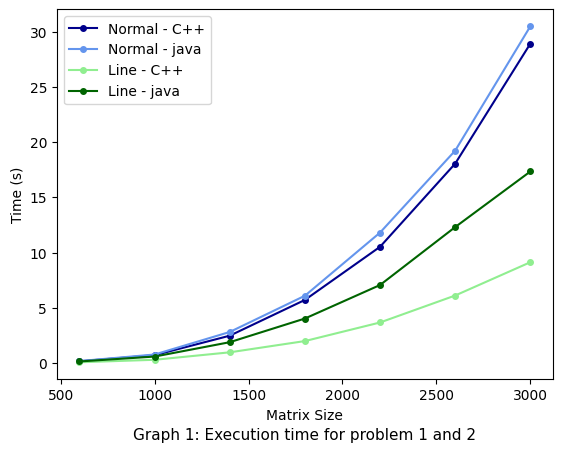

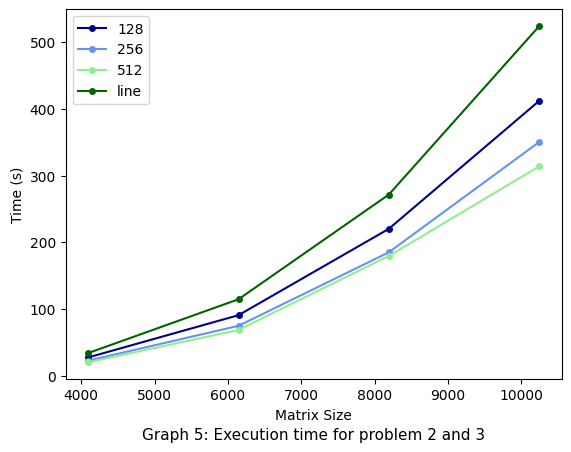

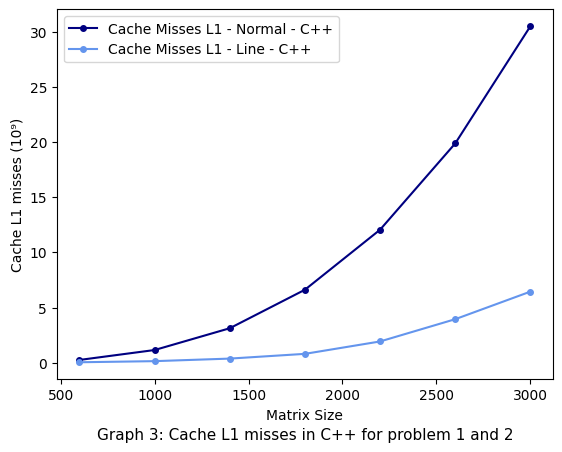

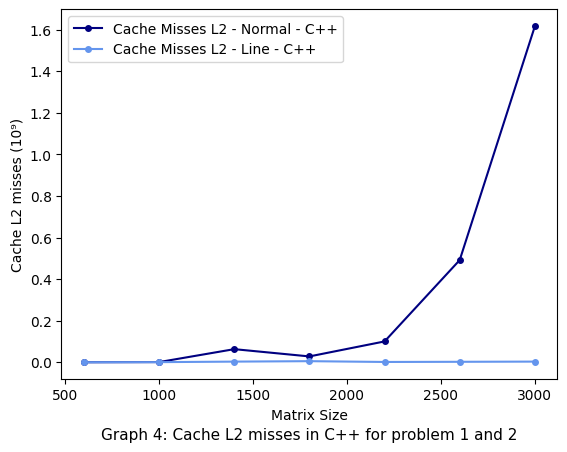

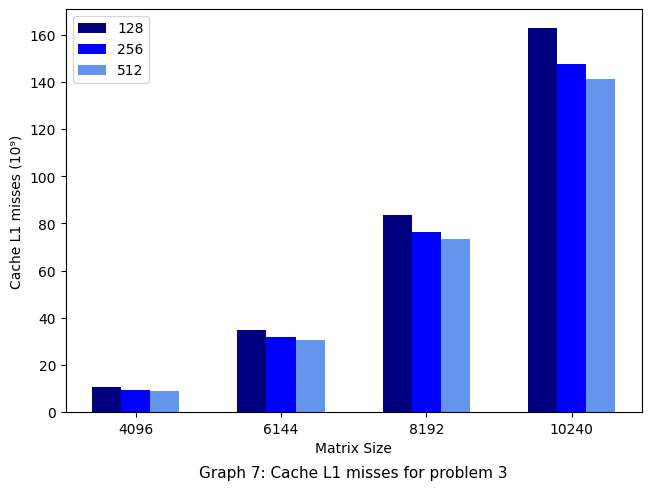

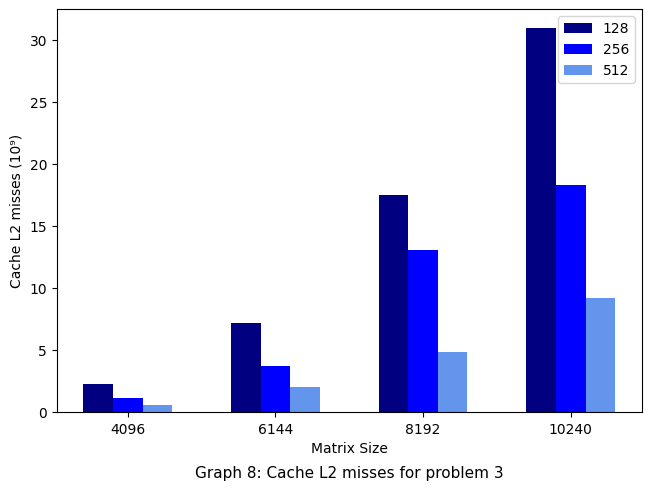

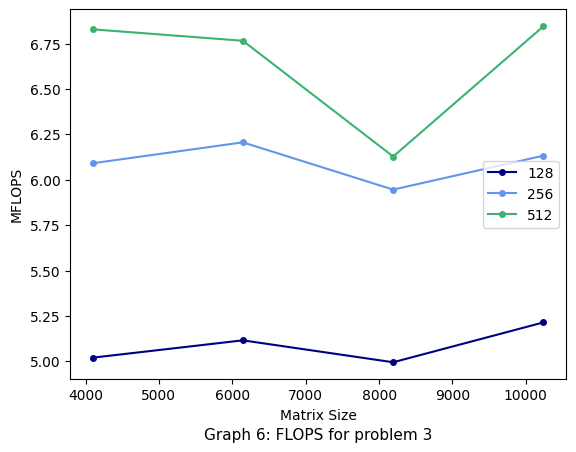

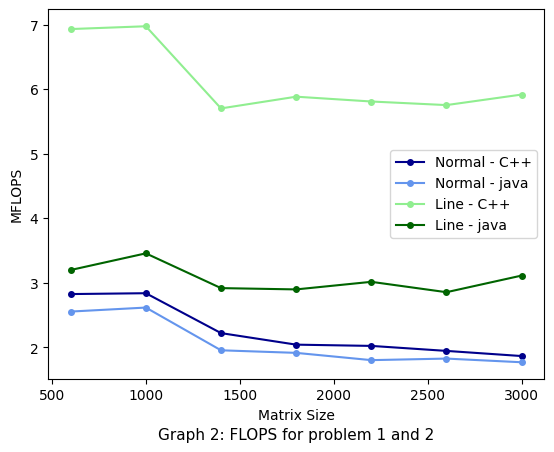

{4096: (23.573760636688494, 5.819347645864899, 0.3637092278665562), 6144: (23.147685411846897, 5.715732654656752, 0.357233290916047), 8192: (22.161645496218075, 5.471545917153877, 0.3419716198221173), 10240: (24.651588022049417, 6.0125472468452985, 0.37578420292783116)}
{4096: (7.738781485792791, 1.9103723209576695, 0.11939827005985434), 6144: (8.89356189299754, 2.1960390952090925, 0.13725244345056828), 8192: (9.19541687352442, 2.270280230745792, 0.141892514421612), 10240: (9.960928964004477, 2.4294806470470816, 0.1518425404404426)}


In [11]:
# Time Analysis
time_multi()
time_block()

# Cache Misses Analysis in Normal and Line
cache_misses_multi(1)
cache_misses_multi(2)

# Cache Misses Analysis in Blocks
cache_misses_block(1)
cache_misses_block(2)

# Blocks
flops_block()
flops_multi()

# Speedup: Add table w/ the following results
print(parallel_analyser(new_multi_parallel1))
print(parallel_analyser(new_multi_parallel2))

# Add speedup for line mult.: Oy - speedup ; Ox - Matrix Size